# Baseline de recommandation des cultures — `/recommend`

**Objectif** : construire une première baseline simple pour `/recommend`, qui servira de référence pour la suite.

Démarche :

- une référence naïve, le `DummyRegressor` ;
- une `LinearRegression` sur quatre jeux de features, évaluée avec deux protocoles de validation ;
- le choix de la baseline, puis ses erreurs par culture.

**Métrique principale : RMSE** (t/ha).
**Métriques complémentaires : MAE** (t/ha) et **R²**.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict

from agritech.config import SEED
from agritech.evaluation import format_cv_metrics
from agritech.modeling import RunInfo, cross_validate_model, run_experiment
from agritech.notification import notify
from agritech.preprocessing import build_pipeline, count_encoded_columns
from agritech.recommend_config import (
    RECOMMEND_CATEGORICAL,
    RECOMMEND_COLUMNS,
    RECOMMEND_DATASET,
    RECOMMEND_FEATURE_SETS,
    RECOMMEND_FEATURES,
    RECOMMEND_KEY,
    RECOMMEND_NUMERIC,
    RECOMMEND_ROWS,
    RECOMMEND_TARGET,
    RECOMMEND_TEST_YEAR,
    RECOMMEND_VALIDATION_YEARS,
)
from agritech.tracking import log_run, run_tags, setup_mlflow
from agritech.training_data import (
    feature_types,
    kfold_cv,
    load_dataset,
    temporal_cv,
    temporal_protocol_params,
    temporal_split,
)

# Données

Dataset produit par le notebook 06 : le dataset historique nettoyé, une ligne par pays, année et culture.

In [2]:
df = load_dataset(RECOMMEND_DATASET, RECOMMEND_ROWS, RECOMMEND_COLUMNS, non_negative=[RECOMMEND_TARGET])

print("clé en double      :", df.duplicated(RECOMMEND_KEY).sum(), f"(clé : {RECOMMEND_KEY})")
print("pays / cultures    :", df["iso3"].nunique(), "/", df["crop"].nunique())
print("années             :", df["year"].min(), "-", df["year"].max())

assert not df.duplicated(RECOMMEND_KEY).any()

fichier            : data/processed/recommend_training_dataset.csv
lignes x colonnes  : (16319, 8)
valeurs manquantes : 0
valeurs < 0        : 0 (yield_t_ha)
clé en double      : 0 (clé : ['iso3', 'year', 'crop'])
pays / cultures    : 115 / 10
années             : 1990 - 2013


**Observations :**

- 115 pays, 10 cultures, 1990-2013 ; clé pays / année / culture unique, aucune valeur manquante ni rendement négatif.

# Jeux de features

Variables d'origine, sans transformation : `crop` et `iso3` catégorielles ; `year`, `avg_temp`, `rain_mm` et
`pesticides_t` numériques. Le feature engineering sera traité dans un notebook dédié. `area`, le nom du pays, n'est pas
une variable du modèle.

| Jeu | Variables | Question testée |
|---|---|---|
| `conditions` | `crop`, `avg_temp`, `rain_mm`, `pesticides_t` | baseline avec les conditions |
| `conditions_year` | `conditions` + `year` | est-ce que l'année aide ? |
| `conditions_country` | `conditions` + `iso3` | est-ce que le pays aide ? |
| `conditions_country_year` | `conditions` + `iso3` + `year` | est-ce que pays + année aident ? |

In [3]:
for jeu, variables in RECOMMEND_FEATURE_SETS.items():
    categorielles, numeriques = feature_types(variables, RECOMMEND_CATEGORICAL, RECOMMEND_NUMERIC)
    n_colonnes = count_encoded_columns(categorielles, numeriques, df)
    print(f"{jeu:24s}: {categorielles} + {numeriques} → {n_colonnes} colonnes après encodage")

pluies_par_pays = df.groupby("iso3")["rain_mm"].nunique()
print(
    f"\nrain_mm : {pluies_par_pays.max()} valeur par pays, "
    f"{df['rain_mm'].nunique()} valeurs distinctes pour {len(pluies_par_pays)} pays"
)

conditions              : ['crop'] + ['avg_temp', 'rain_mm', 'pesticides_t'] → 13 colonnes après encodage
conditions_year         : ['crop'] + ['year', 'avg_temp', 'rain_mm', 'pesticides_t'] → 14 colonnes après encodage
conditions_country      : ['crop', 'iso3'] + ['avg_temp', 'rain_mm', 'pesticides_t'] → 128 colonnes après encodage
conditions_country_year : ['crop', 'iso3'] + ['year', 'avg_temp', 'rain_mm', 'pesticides_t'] → 129 colonnes après encodage

rain_mm : 1 valeur par pays, 114 valeurs distinctes pour 115 pays


**Observations :**

- `rain_mm` a une seule valeur par pays : elle est très liée à `iso3`. Dans les jeux avec le pays, son effet propre ne
  peut plus être séparé de celui du pays.

# Découpage temporel et validation

Les données sont découpées dans le temps :

- **1990-2012 : développement**, pour la validation croisée et le choix des variables et du modèle ;
- **2013 : test final**, réservé à l'évaluation finale du modèle retenu.

In [4]:
X_train, X_test, y_train, y_test = temporal_split(df, RECOMMEND_FEATURES, RECOMMEND_TARGET, RECOMMEND_TEST_YEAR)
print("pays présents seulement dans le test :", sorted(set(X_test["iso3"]) - set(X_train["iso3"])))

# rendement de l'année précédente, même pays et même culture, calculé sur le train
historique = X_train[RECOMMEND_KEY].assign(rendement=y_train)
annee_precedente = historique.assign(year=historique["year"] + 1)
paires = historique.merge(annee_precedente, on=RECOMMEND_KEY, suffixes=("", "_precedent"))
correlation = paires["rendement"].corr(paires["rendement_precedent"])
print(f"\ncorrélation avec le rendement de l'année précédente : {correlation:.3f}")

total   : 16319 lignes, 1990-2013
X_train : (15624, 6), 1990-2012
X_test  : (695, 6), 2013, réservé à l'évaluation finale
y_train : (15624,)
y_test  : (695,)
pays présents seulement dans le test : []

corrélation avec le rendement de l'année précédente : 0.985


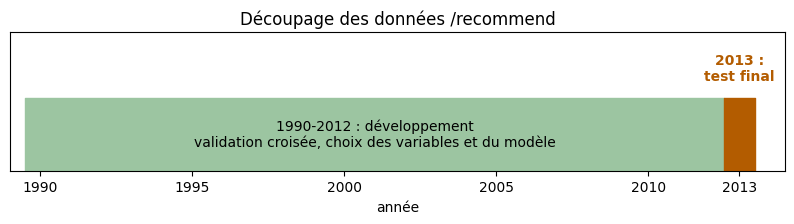

In [5]:
# schéma du découpage : développement sur les années du train, 2013 à part pour le test final
COULEUR_APPRENTISSAGE, COULEUR_VALIDATION, COULEUR_TEST = "#9cc5a1", "#2c7a53", "#b35c00"
debut, fin, annee_test = X_train["year"].min(), X_train["year"].max(), X_test["year"].min()
reperes = sorted({debut, *range(debut + 5, annee_test, 5), annee_test})

figure, axe = plt.subplots(figsize=(10, 1.8))
axe.broken_barh([(debut - 0.5, fin - debut + 1)], (0, 1), color=COULEUR_APPRENTISSAGE)
axe.broken_barh([(annee_test - 0.5, 1)], (0, 1), color=COULEUR_TEST)
axe.text((debut + fin) / 2, 0.5, f"{debut}-{fin} : développement\nvalidation croisée, choix des variables et du modèle",
         ha="center", va="center")
axe.text(annee_test, 1.2, f"{annee_test} :\ntest final", ha="center", va="bottom", color=COULEUR_TEST, fontweight="bold")
axe.set_xlim(debut - 1, annee_test + 1.5)
axe.set_ylim(0, 1.9)
axe.set_xticks(reperes)
axe.set_yticks([])
axe.set_xlabel("année")
axe.set_title("Découpage des données /recommend")
plt.show()

**Observations :**

- Le rendement est très corrélé à celui de l'année précédente : dans un découpage aléatoire, des années voisines du même
  pays et de la même culture se retrouveraient dans l'apprentissage et dans l'évaluation.
- Les 115 pays du test sont présents dans le train.

**Validation temporelle à 5 folds**, sur 1990-2012 uniquement : chaque fold apprend sur toutes les années précédant
l'année validée, puis prédit cette année. Les folds sont les mêmes pour toutes les évaluations.

In [6]:
cv = temporal_cv(X_train["year"], RECOMMEND_VALIDATION_YEARS, RECOMMEND_TEST_YEAR)

validation 2008 : apprentissage 1990-2007 (12152 lignes) | 694 lignes évaluées
validation 2009 : apprentissage 1990-2008 (12846 lignes) | 692 lignes évaluées
validation 2010 : apprentissage 1990-2009 (13538 lignes) | 695 lignes évaluées
validation 2011 : apprentissage 1990-2010 (14233 lignes) | 695 lignes évaluées
validation 2012 : apprentissage 1990-2011 (14928 lignes) | 696 lignes évaluées


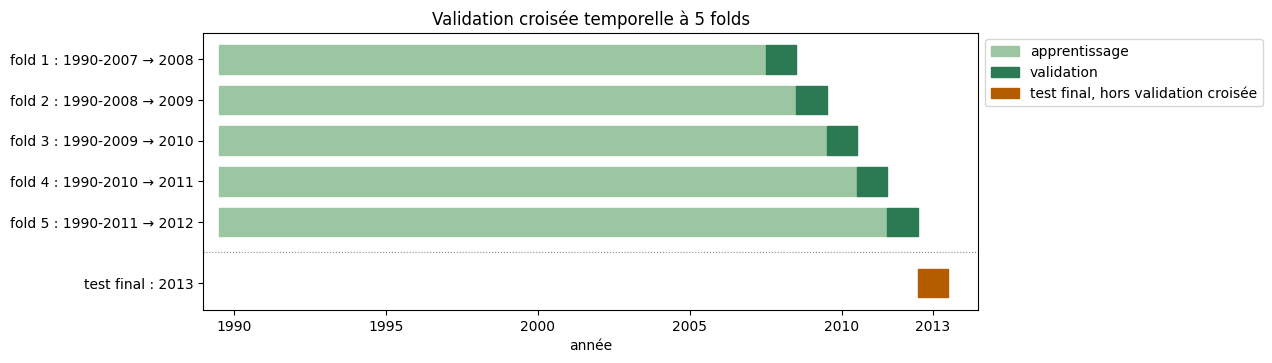

In [7]:
# schéma des 5 folds, tracé à partir de cv ; 2013 apparaît à part, hors validation croisée
figure, axe = plt.subplots(figsize=(10, 3.6))
etiquettes = []
for ligne, (annee, (apprentissage, validation)) in enumerate(zip(RECOMMEND_VALIDATION_YEARS, cv)):
    debut_fold, fin_fold = X_train["year"].iloc[apprentissage].min(), X_train["year"].iloc[apprentissage].max()
    assert fin_fold == annee - 1 and set(X_train["year"].iloc[validation]) == {annee}  # validation = année suivante
    axe.broken_barh([(debut_fold - 0.5, fin_fold - debut_fold + 1)], (ligne - 0.35, 0.7),
                    color=COULEUR_APPRENTISSAGE, label="apprentissage" if ligne == 0 else None)
    axe.broken_barh([(annee - 0.5, 1)], (ligne - 0.35, 0.7),
                    color=COULEUR_VALIDATION, label="validation" if ligne == 0 else None)
    etiquettes.append(f"fold {ligne + 1} : {debut_fold}-{fin_fold} → {annee}")

ligne_test = len(cv) + 0.5
axe.broken_barh([(annee_test - 0.5, 1)], (ligne_test - 0.35, 0.7), color=COULEUR_TEST,
                label="test final, hors validation croisée")
axe.axhline(len(cv) - 0.25, color="#8a8a8a", linewidth=0.8, linestyle=":")
etiquettes.append(f"test final : {annee_test}")
axe.set_yticks(list(range(len(cv))) + [ligne_test], etiquettes)
axe.invert_yaxis()
axe.set_xlim(debut - 1, annee_test + 1.5)
axe.set_xticks(reperes)
axe.set_xlabel("année")
axe.set_title("Validation croisée temporelle à 5 folds")
axe.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

Chaque évaluation temporelle entraîne donc 5 modèles. La RMSE CV moyenne est la moyenne des RMSE obtenues sur 2008,
2009, 2010, 2011 et 2012 ; elle ne correspond pas au score de la seule année 2012.

# Baseline naïve : `DummyRegressor`

Il prédit toujours la moyenne des rendements des années d'apprentissage.

In [8]:
# mêmes tags et mêmes paramètres de protocole pour tous les runs /recommend
experience = setup_mlflow("recommend")
TAGS = run_tags(service="recommend", stage="baseline", notebook="12_recommend_training_baseline.ipynb")
PARAMS_PROTOCOLE = temporal_protocol_params(
    RECOMMEND_DATASET, RECOMMEND_TARGET, X_train, X_test, RECOMMEND_VALIDATION_YEARS, RECOMMEND_TEST_YEAR
)

expérience MLflow : oc_p12_agritech_recommend


In [9]:
print(f"écart-type du rendement dans le train : {y_train.std(ddof=0):.3f} t/ha\n")

# une seule évaluation, en validation temporelle, enregistrée dans MLflow aussitôt
_, cv_dummy = cross_validate_model(DummyRegressor(strategy="mean"), X_train, y_train, cv, verbose=False)
log_run(
    "dummy_baseline_cv",
    TAGS,
    params=PARAMS_PROTOCOLE | {"model": "DummyRegressor", "strategy": "mean", "feature_set": "none", "n_features": 0},
    metrics=cv_dummy,
)
print(f"DummyRegressor : {format_cv_metrics(cv_dummy)}")

écart-type du rendement dans le train : 7.645 t/ha

DummyRegressor : RMSE 8.5025 ± 0.1547 t/ha | MAE 5.9072 ± 0.0921 t/ha | R² -0.0154 ± 0.0017


**Observations :**

- Le `DummyRegressor` a un R² légèrement négatif : la moyenne des années passées prédit un peu moins bien que celle de
  l'année évaluée.

# Comparaison des protocoles

Même modèle, `LinearRegression`, pour les quatre jeux de features, évalués avec deux protocoles sur les lignes
1990-2012 :

- **validation temporelle à 5 folds**, décrite ci-dessus, avec un run MLflow par jeu ;
- **`KFold` classique à 5 folds** : lignes mélangées (`shuffle=True`, graine du projet), sans tenir compte des années.

Soit 4 × 2 = 8 évaluations. Les deux protocoles n'évaluent pas les mêmes années : 2008-2012 pour la validation
temporelle, toutes les années 1990-2012 pour le `KFold`. Leurs RMSE sont donc moins directement comparables que leurs R².

In [10]:
cv_kfold = kfold_cv(len(cv), shuffle=True, seed=SEED)

scores = []
for jeu, variables in RECOMMEND_FEATURE_SETS.items():
    categorielles, numeriques = feature_types(variables, RECOMMEND_CATEGORICAL, RECOMMEND_NUMERIC)

    # validation temporelle : le run MLflow est enregistré pendant l'évaluation
    run = RunInfo(f"linear_regression_{jeu}_cv", jeu, TAGS, PARAMS_PROTOCOLE)
    folds, _ = run_experiment(
        LinearRegression(), X_train, y_train, cv, categorielles, numeriques, run=run, verbose=False
    )
    scores.append(folds.set_axis(RECOMMEND_VALIDATION_YEARS).assign(feature_set=jeu, validation="temporelle"))

    # KFold classique : même modèle, mêmes variables, sans run MLflow
    folds, _ = run_experiment(
        LinearRegression(), X_train, y_train, cv_kfold, categorielles, numeriques, verbose=False
    )
    scores.append(folds.assign(feature_set=jeu, validation="KFold"))

# une ligne par fold : fold = année validée (temporelle) ou numéro de 1 à 5 (KFold)
resultats = pd.concat(scores).rename_axis("fold").reset_index()
resultats = resultats.rename(columns={"rmse": "RMSE", "mae": "MAE", "r2": "R²"})
resultats = resultats[["feature_set", "validation", "fold", "RMSE", "MAE", "R²"]]
# une ligne par évaluation : moyenne des 5 folds
recapitulatif = resultats.groupby(["feature_set", "validation"], sort=False)[["RMSE", "MAE", "R²"]].mean().reset_index()
print(f"{len(recapitulatif)} évaluations LinearRegression : {len(RECOMMEND_FEATURE_SETS)} jeux × 2 protocoles")

validation croisée : KFold(n_splits=5, random_state=42, shuffle=True)


8 évaluations LinearRegression : 4 jeux × 2 protocoles


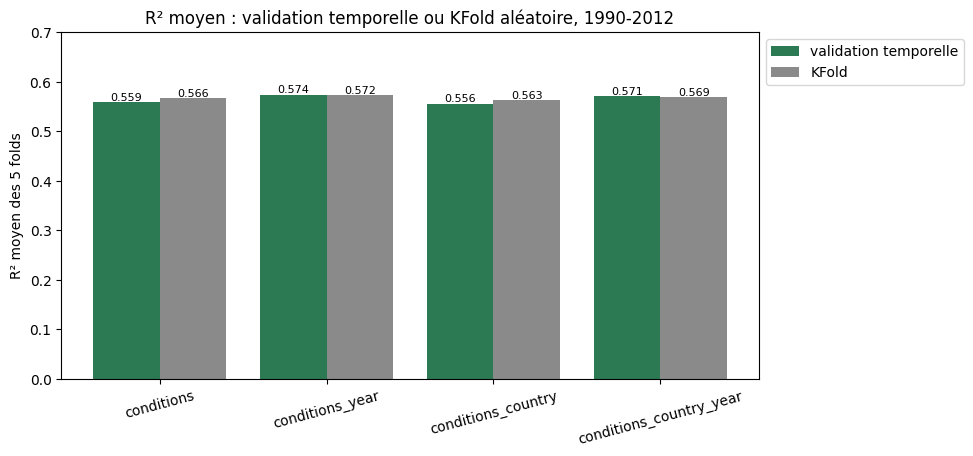

In [11]:
# R² moyen des 5 folds, par jeu et par protocole
r2_moyen = recapitulatif.pivot(index="feature_set", columns="validation", values="R²").loc[list(RECOMMEND_FEATURE_SETS)]

positions = np.arange(len(r2_moyen))
figure, axe = plt.subplots(figsize=(9, 4.5))
for decalage, protocole, couleur, libelle in [
    (-0.2, "temporelle", COULEUR_VALIDATION, "validation temporelle"),
    (0.2, "KFold", "#8a8a8a", "KFold"),
]:
    barres = axe.bar(positions + decalage, r2_moyen[protocole], width=0.4, color=couleur, label=libelle)
    axe.bar_label(barres, fmt="%.3f", fontsize=8)
axe.set_xticks(positions, r2_moyen.index, rotation=15)
axe.set_ylim(0, 0.7)
axe.set_ylabel("R² moyen des 5 folds")
axe.set_title("R² moyen : validation temporelle ou KFold aléatoire, 1990-2012")
axe.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

Le `KFold` mélange toutes les années 1990-2012 : ses RMSE par fold ne correspondent à aucune année précise.

Pour le comparer à la validation temporelle, on recalcule sa RMSE année par année, de 2008 à 2012, avec les mêmes
5 folds : chaque ligne reste prédite par le modèle qui ne l'a pas vue à l'entraînement.

In [12]:
# numéro du fold KFold dans lequel chaque ligne est évaluée
fold_kfold = np.empty(len(X_train), dtype=int)
for numero, (_, evaluation) in enumerate(cv_kfold.split(X_train), start=1):
    fold_kfold[evaluation] = numero

rmse_kfold_par_annee = {}
for jeu, variables in RECOMMEND_FEATURE_SETS.items():
    categorielles, numeriques = feature_types(variables, RECOMMEND_CATEGORICAL, RECOMMEND_NUMERIC)
    pipeline = build_pipeline(LinearRegression(), categorielles, numeriques)
    carres = (cross_val_predict(pipeline, X_train, y_train, cv=cv_kfold) - y_train) ** 2

    # mêmes modèles que l'évaluation KFold : les RMSE par fold doivent être identiques
    rmse_folds = np.sqrt(carres.groupby(fold_kfold).mean())
    assert np.allclose(rmse_folds, resultats.query("feature_set == @jeu and validation == 'KFold'")["RMSE"])

    rmse_kfold_par_annee[jeu] = np.sqrt(carres.groupby(X_train["year"]).mean()).loc[RECOMMEND_VALIDATION_YEARS]
rmse_kfold_par_annee = pd.DataFrame(rmse_kfold_par_annee)
print("KFold : RMSE par fold identiques à l'évaluation, RMSE recalculées par année :", RECOMMEND_VALIDATION_YEARS)

KFold : RMSE par fold identiques à l'évaluation, RMSE recalculées par année : [2008, 2009, 2010, 2011, 2012]


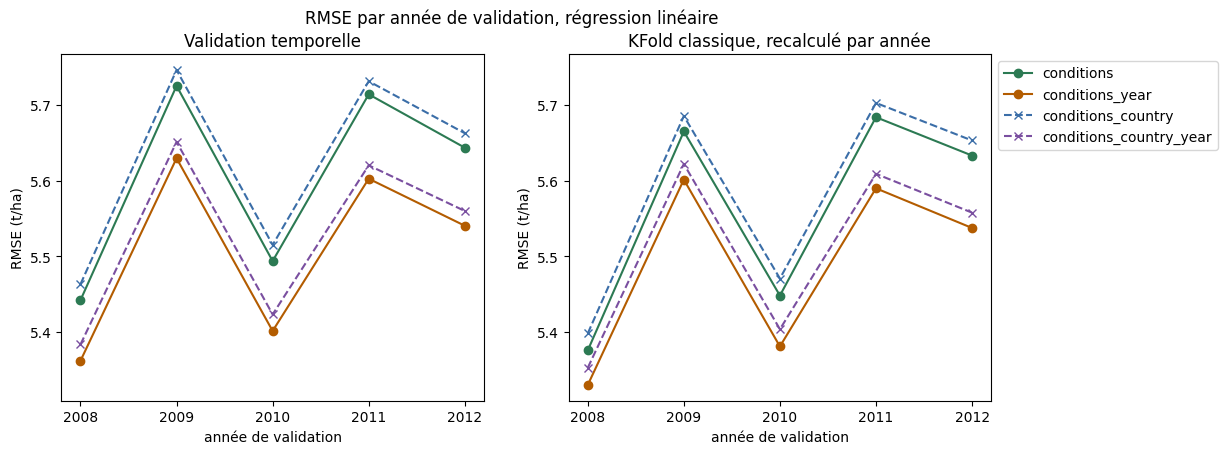

In [13]:
# une couleur par jeu, la même dans les deux panneaux ; pointillés et croix pour les jeux avec le pays
COULEURS = {
    "conditions": "#2c7a53",
    "conditions_year": "#b35c00",
    "conditions_country": "#3b6ea8",
    "conditions_country_year": "#7a4fa0",
}
TRAITS = {jeu: "--" if "country" in jeu else "-" for jeu in COULEURS}
MARQUEURS = {jeu: "x" if "country" in jeu else "o" for jeu in COULEURS}

# mêmes années en abscisse des deux côtés : pour la validation temporelle, chaque fold est une année
rmse_temporelle = resultats.query("validation == 'temporelle'").pivot(index="fold", columns="feature_set", values="RMSE")

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axe, titre, rmse_annees in [
    (axes[0], "Validation temporelle", rmse_temporelle),
    (axes[1], "KFold classique, recalculé par année", rmse_kfold_par_annee),
]:
    for jeu, couleur in COULEURS.items():
        axe.plot(rmse_annees[jeu], color=couleur, linestyle=TRAITS[jeu], marker=MARQUEURS[jeu], label=jeu)
    axe.set_xticks(RECOMMEND_VALIDATION_YEARS)
    axe.set_xlabel("année de validation")
    axe.set_ylabel("RMSE (t/ha)")
    axe.tick_params(axis="y", labelleft=True)  # graduations affichées aussi à droite, malgré sharey
    axe.set_title(titre)
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
figure.suptitle("RMSE par année de validation, régression linéaire")
plt.show()

In [14]:
recapitulatif.round(3)

,feature_set,validation,RMSE,MAE,R²
0,conditions,temporelle,5.604,3.404,0.559
1,conditions,KFold,5.034,3.159,0.566
2,conditions_year,temporelle,5.507,3.460,0.574
3,conditions_year,KFold,4.998,3.151,0.572
4,conditions_country,temporelle,5.624,3.421,0.556
5,conditions_country,KFold,5.054,3.173,0.563
6,conditions_country_year,temporelle,5.528,3.479,0.571
7,conditions_country_year,KFold,5.018,3.165,0.569


**Observations :**

- R² très proches entre les deux protocoles et même classement des jeux : `conditions_year` en tête, `iso3` n'aide pas.
- Sur les mêmes années, les RMSE des deux protocoles sont presque identiques : l'écart visible dans le tableau vient
  surtout des années évaluées.

# Baseline retenue

- Jeu de features : **`conditions_year`**, soit `crop`, `avg_temp`, `rain_mm`, `pesticides_t` et `year`.
- Protocole : **validation temporelle à 5 folds**.
- Scores de référence : RMSE ≈ 5,51 t/ha, R² ≈ 0,574.

Les deux protocoles donnent des résultats proches à ce stade, mais la validation temporelle est retenue : elle
correspond à l'usage, apprendre sur le passé pour prédire l'année suivante.

## Erreurs par culture

`conditions_year` est recréée, puis ses prédictions sont recalculées sur les 5 folds temporels. RMSE et biais de chaque
culture sur les 5 années de validation, cultures triées par rendement moyen.

In [15]:
JEU_RETENU = "conditions_year"


def rmse(erreurs):
    return float(np.sqrt((erreurs**2).mean()))


# prédictions de chaque année de validation par la baseline apprise sur les années précédentes (mêmes folds)
categorielles, numeriques = feature_types(RECOMMEND_FEATURE_SETS[JEU_RETENU], RECOMMEND_CATEGORICAL, RECOMMEND_NUMERIC)
pipeline = build_pipeline(LinearRegression(), categorielles, numeriques)
morceaux = []
for apprentissage, evaluation in cv:
    modele = clone(pipeline).fit(X_train.iloc[apprentissage], y_train.iloc[apprentissage])
    morceau = X_train.iloc[evaluation][["year", "crop"]].assign(rendement=y_train.iloc[evaluation])
    morceau["erreur"] = modele.predict(X_train.iloc[evaluation]) - morceau["rendement"]
    morceaux.append(morceau)
validation = pd.concat(morceaux)

# mêmes folds que la comparaison des protocoles : les RMSE par année doivent être identiques
rmse_par_annee = validation.groupby("year")["erreur"].agg(rmse)
rmse_comparaison = resultats.query("feature_set == @JEU_RETENU and validation == 'temporelle'")["RMSE"]
assert np.allclose(rmse_par_annee, rmse_comparaison)
print(f"{JEU_RETENU} : RMSE par année identiques à la comparaison, moyenne {rmse_par_annee.mean():.3f} t/ha")

conditions_year : RMSE par année identiques à la comparaison, moyenne 5.507 t/ha


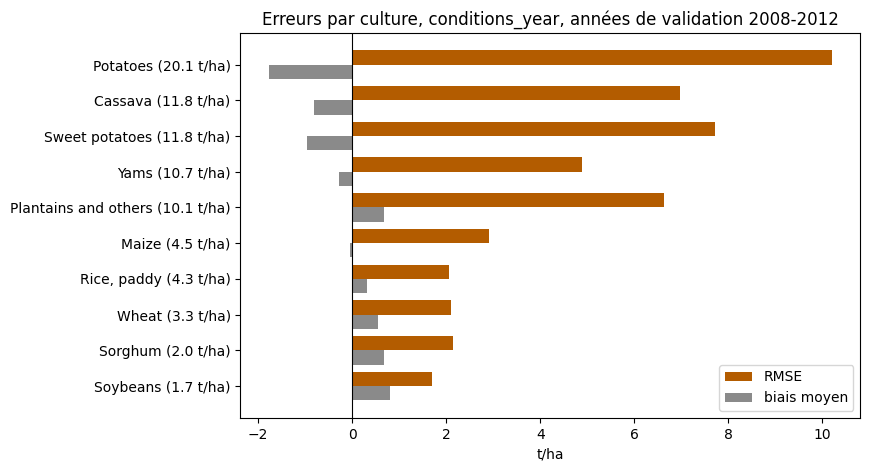

In [16]:
par_culture = (
    validation.groupby("crop")
    .agg(rendement_moyen=("rendement", "mean"), rmse=("erreur", rmse), biais=("erreur", "mean"))
    .sort_values("rendement_moyen")
)
libelles = [f"{culture} ({rendement:.1f} t/ha)" for culture, rendement in par_culture["rendement_moyen"].items()]
positions = np.arange(len(par_culture))
annees = RECOMMEND_VALIDATION_YEARS

figure, axe = plt.subplots(figsize=(8, 5))
axe.barh(positions + 0.2, par_culture["rmse"], height=0.4, color=COULEURS[JEU_RETENU], label="RMSE")
axe.barh(positions - 0.2, par_culture["biais"], height=0.4, color="#8a8a8a", label="biais moyen")
axe.axvline(0, color="black", linewidth=0.8)
axe.set_yticks(positions, libelles)
axe.set_xlabel("t/ha")
axe.set_title(f"Erreurs par culture, {JEU_RETENU}, années de validation {annees[0]}-{annees[-1]}")
axe.legend(loc="lower right")
plt.show()

**Observations :**

- L'erreur grandit avec le rendement : RMSE de 10,2 t/ha pour la pomme de terre, contre environ 2 t/ha pour le soja
  ou le blé.
- Le modèle surestime les cultures à faible rendement (soja, sorgho, blé) et sous-estime la pomme de terre, la patate
  douce et le manioc. C'est cohérent avec un modèle additif : l'effet des conditions et de l'année est le même, en
  t/ha, pour toutes les cultures.

# Conclusion

- RMSE ≈ 5,51 t/ha, à comparer à l'écart-type du rendement dans le train, ≈ 7,65 t/ha ;
- R² ≈ 0,574 : baseline linéaire encore moyenne, avec une marge d'amélioration ;
- features retenues : `crop`, `avg_temp`, `rain_mm`, `pesticides_t`, `year` ;
- validation temporelle retenue plutôt que `KFold` : plus cohérente avec l'usage futur, malgré des résultats proches ici.

In [17]:
retenue = recapitulatif.query("feature_set == @JEU_RETENU and validation == 'temporelle'").iloc[0]
notify(
    "Agritech /recommend",
    f"Baseline terminée — {JEU_RETENU} : RMSE {retenue['RMSE']:.2f} t/ha, R² {retenue['R²']:.3f}"
    " (validation temporelle)",
)